# Flat Purchase Evaluation - Germany

This notebook helps evaluate a flat purchase in Germany with financial calculations and visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Basic Flat Information

Enter the basic details about the flat you're considering.

In [27]:
# Basic Flat Data
flat_data = {
    'Address': 'Example Street 123, Berlin',
    'Purchase Price (€)': 200000,
    'Size (m²)': 75,
    'Rooms': 3,
    'Year Built': 2010,
    'Floor': 2,
    'Monthly Hausgeld (€)': 250,  # Monthly maintenance fee
    'Condition': 'Good',
}

# Display flat information
flat_df = pd.DataFrame(flat_data.items(), columns=['Property', 'Value'])
print("\n" + "="*50)
print("FLAT INFORMATION")
print("="*50)
print(flat_df.to_string(index=False))
print("\nPrice per m²: €{:,.2f}".format(flat_data['Purchase Price (€)'] / flat_data['Size (m²)']))


FLAT INFORMATION
            Property                      Value
             Address Example Street 123, Berlin
  Purchase Price (€)                     200000
           Size (m²)                         75
               Rooms                          3
          Year Built                       2010
               Floor                          2
Monthly Hausgeld (€)                        250
           Condition                       Good

Price per m²: €2,666.67


## 2. Additional Purchase Costs (Nebenkosten)

In Germany, additional costs typically include:
- **Grunderwerbsteuer** (Real Estate Transfer Tax): 3.5% - 6.5% depending on state
- **Notary fees**: ~1.5% - 2%
- **Land Registry fees**: ~0.5%
- **Real Estate Agent commission**: 3% - 7% (if applicable)

In [28]:
# Additional costs (as percentage of purchase price)
purchase_price = flat_data['Purchase Price (€)']

costs = {
    'Grunderwerbsteuer (%)': 3.0,  # fantasy rate
    'Notary fees (%)': 1.5,
    'Land Registry (%)': 0.5,
    'Agent Commission (%)': 3.57,  # 3.57% including VAT (typical)
}

# Calculate actual costs
total_additional_costs = 0
print("\n" + "="*50)
print("ADDITIONAL PURCHASE COSTS (Nebenkosten)")
print("="*50)

for cost_name, percentage in costs.items():
    cost_amount = purchase_price * (percentage / 100)
    total_additional_costs += cost_amount
    print(f"{cost_name}: €{cost_amount:,.2f}")

print("\n" + "-"*50)
print(f"Total Additional Costs: €{total_additional_costs:,.2f}")
print(f"Total Investment Required: €{purchase_price + total_additional_costs:,.2f}")
print(f"Additional costs as % of purchase price: {(total_additional_costs/purchase_price)*100:.2f}%")


ADDITIONAL PURCHASE COSTS (Nebenkosten)
Grunderwerbsteuer (%): €6,000.00
Notary fees (%): €3,000.00
Land Registry (%): €1,000.00
Agent Commission (%): €7,140.00

--------------------------------------------------
Total Additional Costs: €17,140.00
Total Investment Required: €217,140.00
Additional costs as % of purchase price: 8.57%


## 3. Mortgage Calculation

Calculate monthly mortgage payments with different scenarios.

In [29]:
# Mortgage parameters
down_payment = 100000  # Your down payment (Eigenkapital)
loan_amount = purchase_price - down_payment
loan_term_years = 30

print("\n" + "="*50)
print("MORTGAGE PARAMETERS")
print("="*50)
print(f"Purchase Price: €{purchase_price:,.2f}")
print(f"Down Payment: €{down_payment:,.2f} ({(down_payment/purchase_price)*100:.1f}%)")
print(f"Loan Amount: €{loan_amount:,.2f}")
print(f"Loan Term: {loan_term_years} years")


MORTGAGE PARAMETERS
Purchase Price: €200,000.00
Down Payment: €100,000.00 (50.0%)
Loan Amount: €100,000.00
Loan Term: 30 years


In [30]:
def calculate_monthly_payment(principal, annual_rate, years):
    """
    Calculate monthly mortgage payment using the formula:
    M = P * [r(1+r)^n] / [(1+r)^n - 1]
    
    where:
    M = Monthly payment
    P = Principal loan amount
    r = Monthly interest rate
    n = Total number of payments
    """
    monthly_rate = annual_rate / 12 / 100
    num_payments = years * 12
    
    if monthly_rate == 0:
        return principal / num_payments
    
    monthly_payment = principal * (monthly_rate * (1 + monthly_rate)**num_payments) / \
                     ((1 + monthly_rate)**num_payments - 1)
    
    return monthly_payment

def calculate_total_interest(principal, monthly_payment, years):
    """Calculate total interest paid over the loan term"""
    total_paid = monthly_payment * years * 12
    return total_paid - principal

# Test different interest rates
interest_rates = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

results = []
for rate in interest_rates:
    monthly = calculate_monthly_payment(loan_amount, rate, loan_term_years)
    total_interest = calculate_total_interest(loan_amount, monthly, loan_term_years)
    total_cost = monthly * loan_term_years * 12
    
    results.append({
        'Interest Rate (%)': rate,
        'Monthly Payment (€)': monthly,
        'Total Interest (€)': total_interest,
        'Total Cost (€)': total_cost
    })

mortgage_df = pd.DataFrame(results)
print("\n" + "="*50)
print("MORTGAGE PAYMENT SCENARIOS")
print("="*50)
print(mortgage_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))


MORTGAGE PAYMENT SCENARIOS
 Interest Rate (%)  Monthly Payment (€)  Total Interest (€)  Total Cost (€)
              2.00               369.62           33,063.01      133,063.01
              2.50               395.12           42,243.52      142,243.52
              3.00               421.60           51,777.45      151,777.45
              3.50               449.04           61,656.09      161,656.09
              4.00               477.42           71,869.51      171,869.51
              4.50               506.69           82,406.71      182,406.71
              5.00               536.82           93,255.78      193,255.78


## 4. Monthly Costs Overview

Calculate total monthly costs including mortgage and maintenance.

In [31]:
# Select a specific interest rate for detailed analysis
selected_rate = 3.5  # Current typical rate in Germany
monthly_mortgage = calculate_monthly_payment(loan_amount, selected_rate, loan_term_years)
monthly_hausgeld = flat_data['Monthly Hausgeld (€)']

# Additional monthly costs
monthly_costs = {
    'Mortgage Payment': monthly_mortgage,
    'Hausgeld (Maintenance)': monthly_hausgeld,
    'Property Tax (est.)': 50,  # Grundsteuer - varies by location
    'Insurance (est.)': 30,  # Building insurance
    'Utilities (est.)': 150,  # Heating, water, etc.
}

total_monthly = sum(monthly_costs.values())

print("\n" + "="*50)
print(f"MONTHLY COSTS BREAKDOWN (at {selected_rate}% interest)")
print("="*50)
for item, cost in monthly_costs.items():
    print(f"{item:.<40} €{cost:>8,.2f}")
print("-"*50)
print(f"{'Total Monthly Costs':.<40} €{total_monthly:>8,.2f}")
print(f"\nAnnual Costs: €{total_monthly * 12:,.2f}")


MONTHLY COSTS BREAKDOWN (at 3.5% interest)
Mortgage Payment........................ €  449.04
Hausgeld (Maintenance).................. €  250.00
Property Tax (est.)..................... €   50.00
Insurance (est.)........................ €   30.00
Utilities (est.)........................ €  150.00
--------------------------------------------------
Total Monthly Costs..................... €  929.04

Annual Costs: €11,148.54


## 5. Visualizations

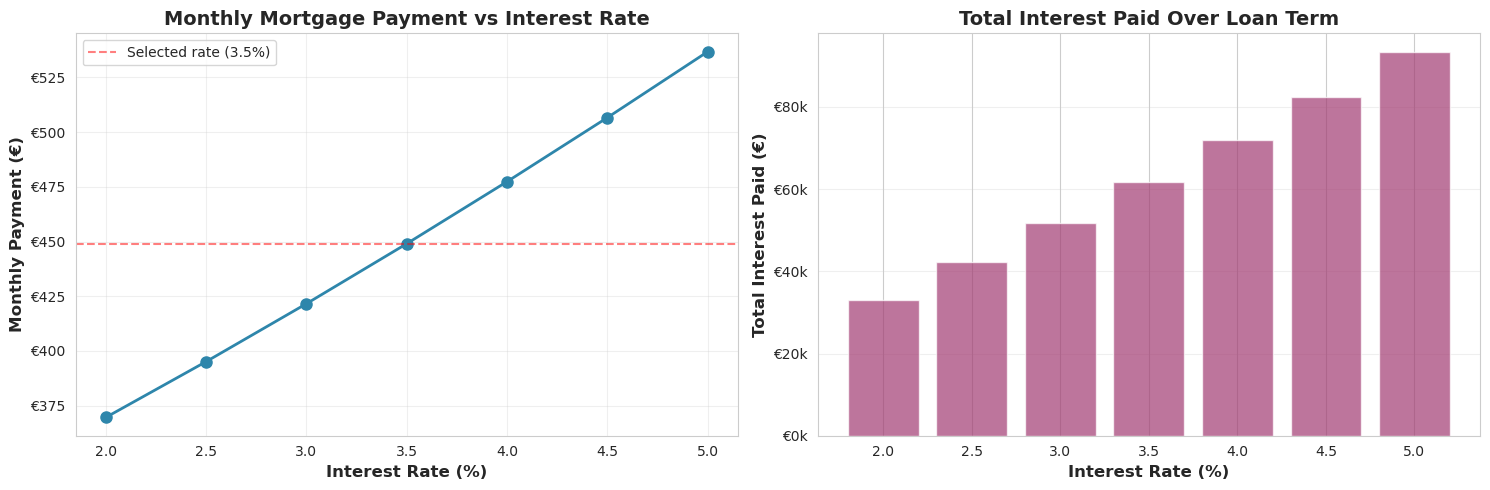

In [32]:
# Plot 1: Monthly Payment vs Interest Rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Monthly payment comparison
ax1.plot(mortgage_df['Interest Rate (%)'], mortgage_df['Monthly Payment (€)'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.set_xlabel('Interest Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Monthly Payment (€)', fontsize=12, fontweight='bold')
ax1.set_title('Monthly Mortgage Payment vs Interest Rate', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=monthly_mortgage, color='red', linestyle='--', alpha=0.5, 
            label=f'Selected rate ({selected_rate}%)')
ax1.legend()

# Format y-axis as currency
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

# Total interest paid
ax2.bar(mortgage_df['Interest Rate (%)'].astype(str), 
        mortgage_df['Total Interest (€)'], 
        color='#A23B72', alpha=0.7)
ax2.set_xlabel('Interest Rate (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Interest Paid (€)', fontsize=12, fontweight='bold')
ax2.set_title('Total Interest Paid Over Loan Term', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Format y-axis as currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

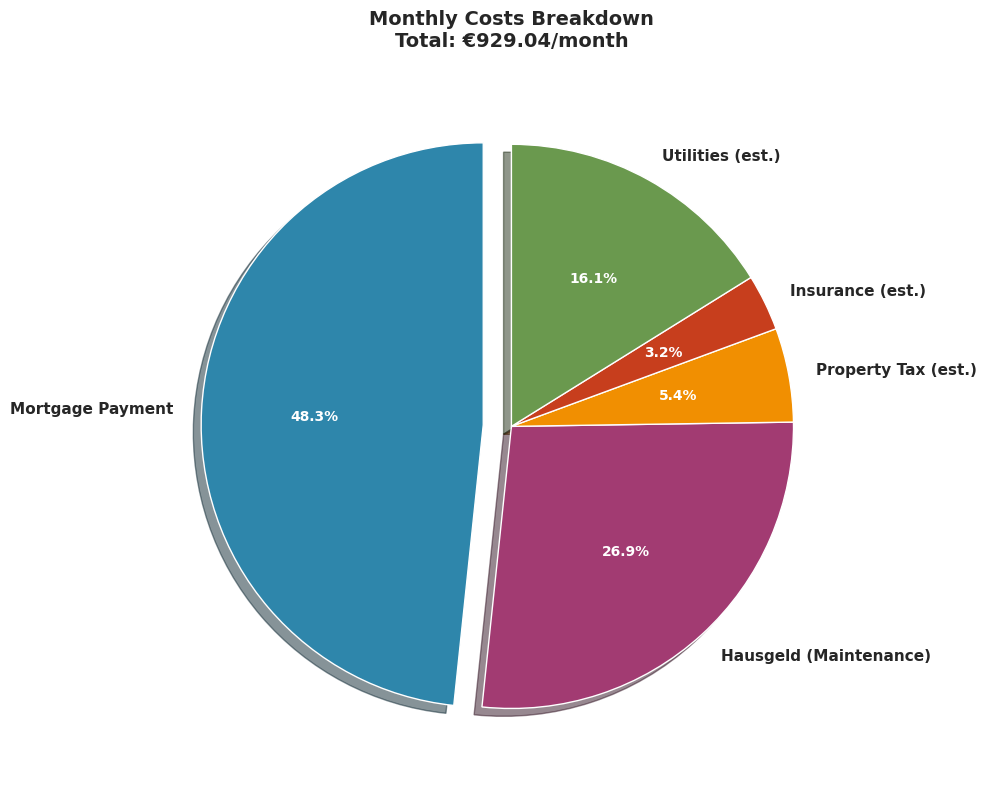

In [33]:
# Plot 2: Monthly Costs Breakdown (Pie Chart)
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
explode = (0.1, 0, 0, 0, 0)  # Explode the mortgage slice

wedges, texts, autotexts = ax.pie(monthly_costs.values(), 
                                    labels=monthly_costs.keys(),
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    explode=explode,
                                    shadow=True)

# Enhance text
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
    
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title(f'Monthly Costs Breakdown\nTotal: €{total_monthly:,.2f}/month', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

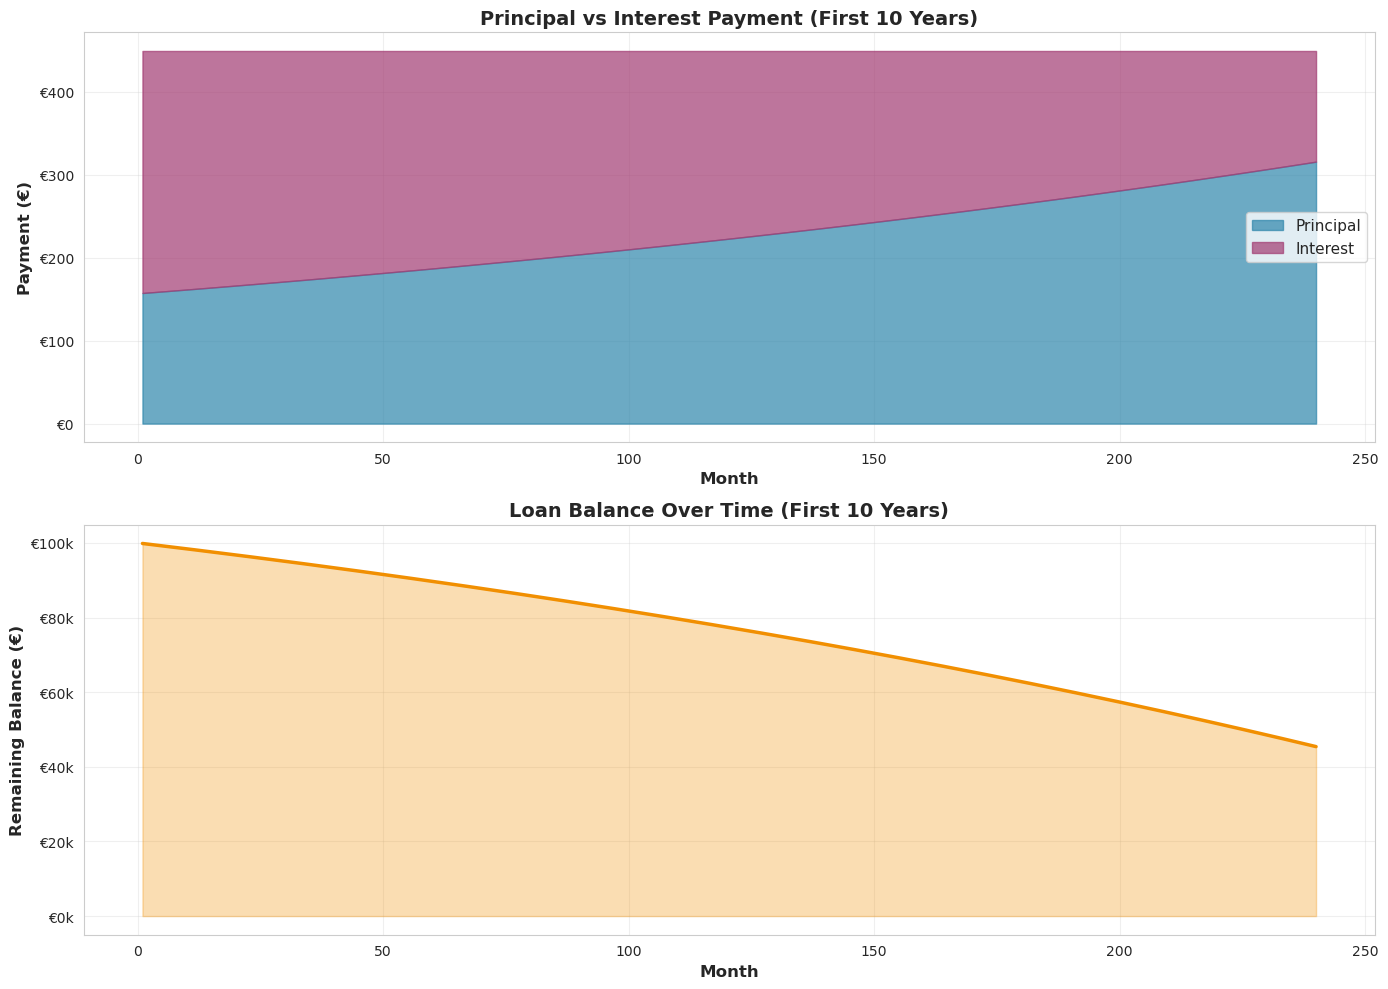


After 10 years:
Remaining balance: €45,410.40
Principal paid: €54,589.60
Percentage paid off: 54.6%


In [34]:
# Plot 3: Amortization Schedule (First 10 years)
def create_amortization_schedule(principal, annual_rate, years):
    """Create detailed amortization schedule"""
    monthly_payment = calculate_monthly_payment(principal, annual_rate, years)
    monthly_rate = annual_rate / 12 / 100
    
    schedule = []
    balance = principal
    
    for month in range(1, years * 12 + 1):
        interest_payment = balance * monthly_rate
        principal_payment = monthly_payment - interest_payment
        balance -= principal_payment
        
        schedule.append({
            'Month': month,
            'Payment': monthly_payment,
            'Principal': principal_payment,
            'Interest': interest_payment,
            'Balance': max(0, balance)
        })
    
    return pd.DataFrame(schedule)

# Create amortization schedule
amort_df = create_amortization_schedule(loan_amount, selected_rate, loan_term_years)

# Plot first 10 years
months_to_plot = 240  # 20 years
plot_data = amort_df.head(months_to_plot)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Principal vs Interest over time
ax1.fill_between(plot_data['Month'], 0, plot_data['Principal'], 
                  alpha=0.7, label='Principal', color='#2E86AB')
ax1.fill_between(plot_data['Month'], plot_data['Principal'], 
                  plot_data['Principal'] + plot_data['Interest'], 
                  alpha=0.7, label='Interest', color='#A23B72')
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Payment (€)', fontsize=12, fontweight='bold')
ax1.set_title('Principal vs Interest Payment (First 10 Years)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

# Remaining balance over time
ax2.plot(plot_data['Month'], plot_data['Balance'], 
         linewidth=2.5, color='#F18F01')
ax2.fill_between(plot_data['Month'], 0, plot_data['Balance'], 
                  alpha=0.3, color='#F18F01')
ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Remaining Balance (€)', fontsize=12, fontweight='bold')
ax2.set_title('Loan Balance Over Time (First 10 Years)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:,.0f}k'))

plt.tight_layout()
plt.show()

print(f"\nAfter 10 years:")
print(f"Remaining balance: €{plot_data.iloc[-1]['Balance']:,.2f}")
print(f"Principal paid: €{loan_amount - plot_data.iloc[-1]['Balance']:,.2f}")
print(f"Percentage paid off: {((loan_amount - plot_data.iloc[-1]['Balance'])/loan_amount)*100:.1f}%")

## 6. Investment Analysis

Compare buying vs renting and calculate potential returns.

In [35]:
# Rental comparison
estimated_monthly_rent = 1200  # What you would pay in rent for similar flat
estimated_rental_income = 1100  # What you could rent this flat for (if investment)

print("\n" + "="*50)
print("RENT VS BUY COMPARISON")
print("="*50)
print(f"Monthly rent (similar flat): €{estimated_monthly_rent:,.2f}")
print(f"Monthly ownership cost: €{total_monthly:,.2f}")
print(f"Monthly difference: €{total_monthly - estimated_monthly_rent:,.2f}")
print(f"\nAnnual rent: €{estimated_monthly_rent * 12:,.2f}")
print(f"Annual ownership cost: €{total_monthly * 12:,.2f}")

print("\n" + "="*50)
print("INVESTMENT METRICS (if renting out)")
print("="*50)
annual_rental_income = estimated_rental_income * 12
annual_costs = (monthly_hausgeld + 50 + 30) * 12  # Hausgeld + tax + insurance
net_rental_income = annual_rental_income - annual_costs
gross_yield = (annual_rental_income / purchase_price) * 100
net_yield = (net_rental_income / purchase_price) * 100

print(f"Annual rental income: €{annual_rental_income:,.2f}")
print(f"Annual costs (excl. mortgage): €{annual_costs:,.2f}")
print(f"Net rental income: €{net_rental_income:,.2f}")
print(f"\nGross rental yield: {gross_yield:.2f}%")
print(f"Net rental yield: {net_yield:.2f}%")
print(f"\nPrice-to-rent ratio: {purchase_price / annual_rental_income:.1f}x")
print("(Lower is better; <15 typically favors buying, >20 favors renting)")


RENT VS BUY COMPARISON
Monthly rent (similar flat): €1,200.00
Monthly ownership cost: €929.04
Monthly difference: €-270.96

Annual rent: €14,400.00
Annual ownership cost: €11,148.54

INVESTMENT METRICS (if renting out)
Annual rental income: €13,200.00
Annual costs (excl. mortgage): €3,960.00
Net rental income: €9,240.00

Gross rental yield: 6.60%
Net rental yield: 4.62%

Price-to-rent ratio: 15.2x
(Lower is better; <15 typically favors buying, >20 favors renting)


In [36]:
# Plot 4: Comparison scenarios
years_projection = 15
annual_appreciation = 0.02  # 2% annual property value increase
annual_rent_increase = 0.015  # 1.5% annual rent increase

projection = []
for year in range(years_projection + 1):
    property_value = purchase_price * (1 + annual_appreciation) ** year
    remaining_balance = amort_df[amort_df['Month'] == year * 12]['Balance'].values[0] if year * 12 < len(amort_df) else 0
    equity = property_value - remaining_balance
    cumulative_rent = sum([estimated_monthly_rent * 12 * (1 + annual_rent_increase) ** y for y in range(year + 1)])
    
    projection.append({
        'Year': year,
        'Property Value': property_value,
        'Equity': equity,
        'Cumulative Rent Paid': cumulative_rent
    })

proj_df = pd.DataFrame(projection)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(proj_df['Year'], proj_df['Property Value'], 
        marker='o', linewidth=2.5, markersize=6, label='Property Value', color='#2E86AB')
ax.plot(proj_df['Year'], proj_df['Equity'], 
        marker='s', linewidth=2.5, markersize=6, label='Your Equity', color='#6A994E')
ax.plot(proj_df['Year'], proj_df['Cumulative Rent Paid'], 
        marker='^', linewidth=2.5, markersize=6, label='Cumulative Rent (if renting)', 
        color='#A23B72', linestyle='--')

ax.set_xlabel('Years', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (€)', fontsize=12, fontweight='bold')
ax.set_title(f'Property Value vs Equity vs Rent Over {years_projection} Years', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:,.0f}k'))

plt.tight_layout()
plt.show()

print(f"\nAfter {years_projection} years:")
print(f"Estimated property value: €{proj_df.iloc[-1]['Property Value']:,.2f}")
print(f"Your equity: €{proj_df.iloc[-1]['Equity']:,.2f}")
print(f"Total rent paid (if renting): €{proj_df.iloc[-1]['Cumulative Rent Paid']:,.2f}")
print(f"\nNet wealth difference: €{proj_df.iloc[-1]['Equity'] - proj_df.iloc[-1]['Cumulative Rent Paid']:,.2f}")

IndexError: index 0 is out of bounds for axis 0 with size 0

## 7. Summary & Decision Factors

Key considerations for your decision:

In [ ]:
print("\n" + "="*70)
print("SUMMARY - KEY METRICS")
print("="*70)
print(f"\n📍 Property: {flat_data['Address']}")
print(f"💰 Purchase Price: €{purchase_price:,.2f}")
print(f"💵 Total Investment (incl. fees): €{purchase_price + total_additional_costs:,.2f}")
print(f"📊 Price per m²: €{purchase_price / flat_data['Size (m²)']:,.2f}")
print(f"\n🏦 Loan Amount: €{loan_amount:,.2f}")
print(f"📈 Interest Rate: {selected_rate}%")
print(f"💳 Monthly Mortgage: €{monthly_mortgage:,.2f}")
print(f"🏠 Total Monthly Costs: €{total_monthly:,.2f}")
print(f"\n📅 Total Interest (30 years): €{calculate_total_interest(loan_amount, monthly_mortgage, loan_term_years):,.2f}")
print(f"💸 Total Cost of Ownership (30 years): €{(monthly_mortgage * 360) + down_payment:,.2f}")

print("\n" + "="*70)
print("DECISION FACTORS TO CONSIDER")
print("="*70)
print("\n✅ Pros of Buying:")
print("   • Building equity instead of paying rent")
print("   • Property appreciation potential")
print("   • Stability and freedom to modify")
print("   • Forced savings through mortgage payments")
print("   • Tax benefits (in some cases)")
print("\n⚠️  Cons of Buying:")
print("   • Less flexibility to move")
print("   • Maintenance and repair responsibilities")
print("   • Upfront costs (Nebenkosten)")
print("   • Market risk (property values can decrease)")
print("   • Interest rate risk (if variable rate)")
print("\n💡 Questions to Ask:")
print("   • How long do you plan to stay? (5+ years typically needed)")
print("   • Is your income stable enough for mortgage payments?")
print("   • Do you have emergency fund for repairs?")
print("   • How does this compare to market prices in the area?")
print("   • What is the neighborhood development potential?")
print("="*70)